---
title: Do SOTA architectures fully exploit SST information?
exports:
  - format: pdf
    template: arxiv_nips
    output: exports/SOTA-of-SST-Exploitation.pdf
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set matplotlib style for print-friendly plots (white background)
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['text.color'] = 'black'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['legend.facecolor'] = 'white'
plt.rcParams['legend.edgecolor'] = 'black'


In [2]:
df_repro = pd.read_csv('reproduction/speaker-verification.csv')
df_paper = pd.read_csv('paper/speaker-verification.csv')
df_repro

,run_id,run_name,dataset,architecture,train_strategy,test_strategy,eer_mean,eer_std
0,5ecaecvs,CNN-timit-OS/final,timit,CNN,OS,OS,5.221478,0.082623
1,5ecaecvs,CNN-timit-OS/final,timit,CNN,OS,SS,11.221982,0.870683
2,5ecaecvs,CNN-timit-OS/final,timit,CNN,OS,SU,11.357626,0.650520
3,b7mqjubc,CNN-timit-SS/final,timit,CNN,SS,OS,7.828465,0.358819
4,b7mqjubc,CNN-timit-SS/final,timit,CNN,SS,SS,5.293670,0.167192
5,b7mqjubc,CNN-timit-SS/final,timit,CNN,SS,SU,5.192398,0.182284
6,p0o3v8w8,Conformer-timit-OS/final,timit,Conformer,OS,OS,2.381912,0.071319
7,p0o3v8w8,Conformer-timit-OS/final,timit,Conformer,OS,SS,6.955571,0.620567
8,p0o3v8w8,Conformer-timit-OS/final,timit,Conformer,OS,SU,8.055562,0.688553
9,wpoh7dv7,Conformer-timit-SS/final,timit,Conformer,SS,OS,3.217527,0.148393


# Introduction

@doi:10.1145/1631272.1631300 evaluates human performance on a Speaker Clustering (SC) task and report a Diarization Error Rate (DER) of 2% on original speech ("dataset 3"), 28% on resynthesized feature vectors ("dataset 2") and 33% on resynthesized speaker models ("dataset 1") (@doi:10.1145/1631272.1631300, Table 2).

Furthermore, the authors argue that the results on dataset 2 contain high participant variability: Given more time, some of the participants were able to cluster the resynthesized feature vectors nearly perfectly. Interestingly, this was not the case for dataset 1 (the resynthesized speaker models). This leads the authors to the conclusion that "what is difficult on the audible features becomes impossible on the audible models" and that most useful information disappears in the "modeling stage": **HOW MUCH INFORMATION DISAPPEARED???**

They defined the "modeling stage" as the part of the speaker-clustering pipeline in which the extracted acoustic features are used to train a speaker model. The speaker models trained in @doi:10.1145/1631272.1631300 were Gaussian Mixture Models (GMMs). These models treat the features largely as collections of independent vectors, completely ignoring supra-segmental temporal information (SST) in audio signals.

Based on these findings, @doi:10.1016/j.patrec.2024.03.016 introduced a "test to quantify to what extend the performance of state-of-the-art neural networks for speaker recognition can be explained by modelling SST". The authors compared how different model architectures trained on original or shuffled audio data perform when tested against original and shuffled audio data: The performance gap serves as an indication of how well SST is exploited as temporal information is destroyed during shuffling.

# Reproduction of the Experiment

All experiments in @doi:10.1016/j.patrec.2024.03.016 were conducted on TIMIT and Voxceleb datasets. Although TIMIT is too small for conducting tests with Deep Neural Networks (DNNs), it was only used to verify the reproduction. @figure-paper-vs-reproduction shows the results of reproduction for both, TIMIT and VoxCeleb datasets. Based on these results, we deem the reproduction as successful and will focus on the VoxCeleb dataset only for the rest of the discussion.

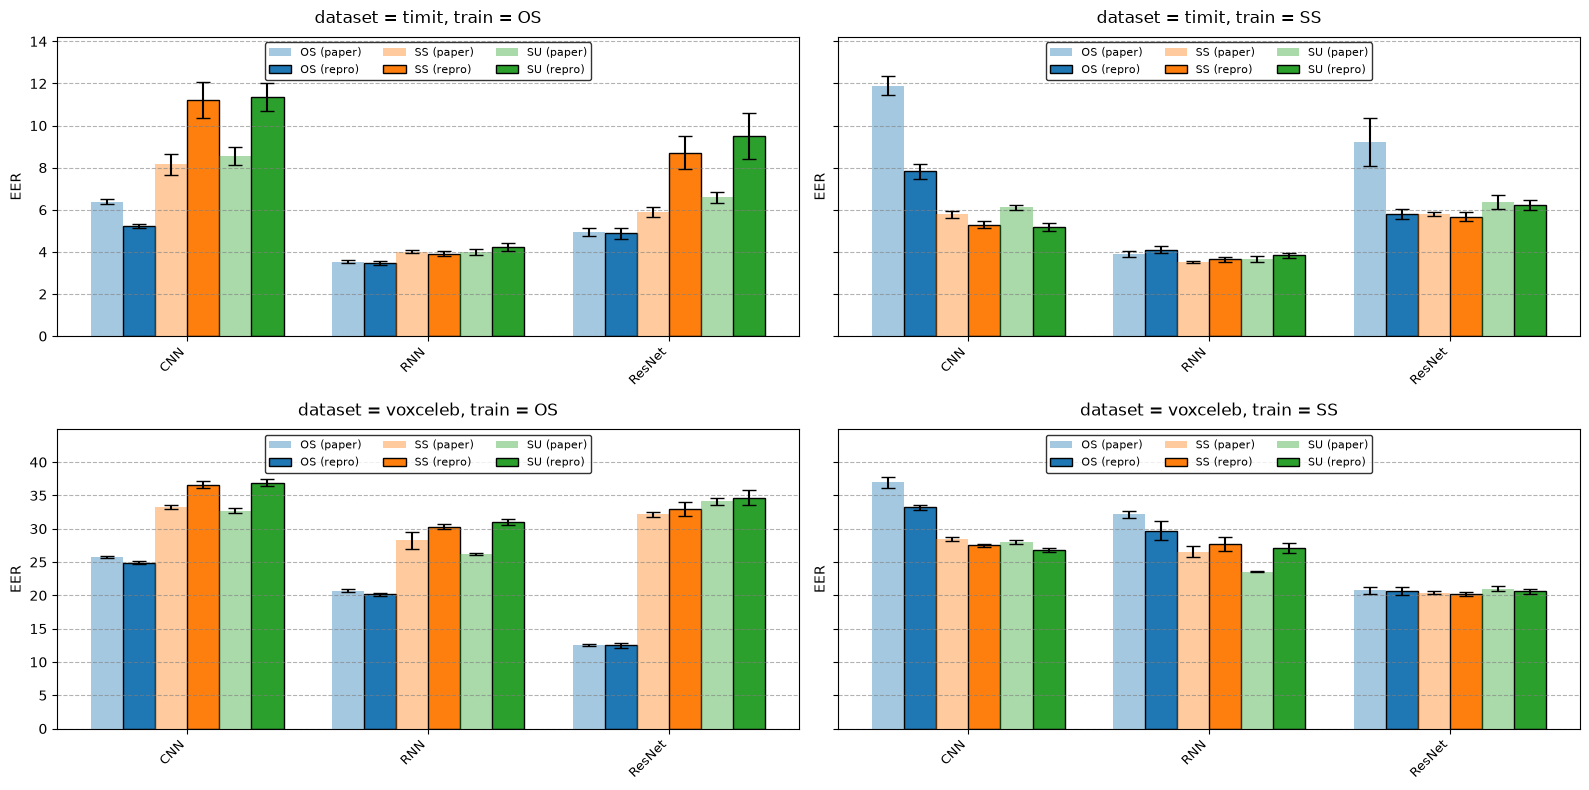

In [3]:
#| label: figure-paper-vs-reproduction
#| caption: Experiment reproduction compared to the original paper results (@doi:10.1016/j.patrec.2024.03.016) for TIMIT and VoxCeleb datasets.

# Filter for OS and SS training strategies only
df_filtered_repro = df_repro[df_repro['train_strategy'].isin(['OS', 'SS'])].copy()
df_filtered_paper = df_paper[df_paper['train_strategy'].isin(['OS', 'SS'])].copy()

# Define fixed architecture order
architectures = ['CNN', 'RNN', 'ResNet']

# Get unique datasets and training strategies
datasets = sorted(df_filtered_repro['dataset'].unique())
train_strategies = sorted(df_filtered_repro['train_strategy'].unique())
test_strategies = sorted(df_filtered_repro['test_strategy'].unique())

# Set up the 2x2 grid: rows=datasets, cols=training_strategies
fig, axes = plt.subplots(len(datasets), len(train_strategies),
                         figsize=(16, 8), sharey='row')

# If only one row or column, axes will be 1D, so we need to handle that
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
if len(train_strategies) == 1:
    axes = axes.reshape(-1, 1)

# Define colors for test strategies
colors = {'OS': '#1f77b4', 'SS': '#ff7f0e', 'SU': '#2ca02c'}
labels = {'OS': 'OS (repro)', 'SS': 'SS (repro)', 'SU': 'SU (repro)'}

# Find global max for y-axis alignment (from both repro and paper)
# Calculate max per dataset for y-axis alignment
dataset_max = {}
for dataset in datasets:
    dataset_data_repro = df_filtered_repro[df_filtered_repro['dataset'] == dataset]
    dataset_data_paper = df_filtered_paper[df_filtered_paper['dataset'] == dataset]
    eer_max_repro = dataset_data_repro['eer_mean'] + dataset_data_repro['eer_std']
    eer_max_paper = dataset_data_paper['eer_mean'] + dataset_data_paper['eer_std']
    all_eer_max = pd.concat([eer_max_repro, eer_max_paper])
    dataset_max[dataset] = max(all_eer_max) * 1.15

# Determine bar width based on number of test strategies
n_test = len(test_strategies)
bar_width = 0.8 / (n_test * 2)

# Plot for each dataset and training strategy
for i, dataset in enumerate(datasets):
    for j, train_strategy in enumerate(train_strategies):
        ax = axes[i, j]
        
        # Get data (repro)
        subset_repro = df_filtered_repro[(df_filtered_repro['dataset'] == dataset) &
                              (df_filtered_repro['train_strategy'] == train_strategy)]
        
        # Get data (paper)
        subset_paper = df_filtered_paper[(df_filtered_paper['dataset'] == dataset) &
                              (df_filtered_paper['train_strategy'] == train_strategy)]
        
        # Get architectures (preserving order)
        subset_architectures = [arch for arch in architectures if arch in subset_repro['architecture'].unique()]
        
        if not subset_architectures:
            ax.set_title(f'{dataset}, Train: {train_strategy}', fontsize=12, pad=10)
            continue
        
        n_arch = len(subset_architectures)
        x = np.arange(n_arch)
        
        # Plot each test strategy
        for k, test_strategy in enumerate(test_strategies):
            paper_offset = (k * 2 - (n_test * 2 - 1) / 2) * bar_width
            repro_offset = (k * 2 + 1 - (n_test * 2 - 1) / 2) * bar_width
            
            # Paper shadow bars
            paper_arch_to_eer = {}
            paper_arch_to_std = {}
            if len(subset_paper) > 0:
                test_data_paper = subset_paper[subset_paper['test_strategy'] == test_strategy]
                for _, row in test_data_paper.iterrows():
                    paper_arch_to_eer[row['architecture']] = row['eer_mean']
                    paper_arch_to_std[row['architecture']] = row['eer_std']
            
            paper_means = [paper_arch_to_eer.get(arch, None) for arch in subset_architectures]
            paper_stds = [paper_arch_to_std.get(arch, None) for arch in subset_architectures]
            
            paper_x, paper_means_filt, paper_stds_filt = [], [], []
            for idx, (mean, std) in enumerate(zip(paper_means, paper_stds)):
                if mean is not None:
                    paper_x.append(x[idx] + paper_offset)
                    paper_means_filt.append(mean)
                    paper_stds_filt.append(std)
            
            if len(paper_x) > 0:
                ax.bar(paper_x, paper_means_filt, bar_width,
                       yerr=paper_stds_filt, capsize=5,
                       color=colors[test_strategy],
                       alpha=0.4, edgecolor='none',
                       label=f'{test_strategy} (paper)')
            
            # Repro solid bars
            test_data_repro = subset_repro[subset_repro['test_strategy'] == test_strategy]
            arch_to_eer = {}
            arch_to_std = {}
            for _, row in test_data_repro.iterrows():
                arch_to_eer[row['architecture']] = row['eer_mean']
                arch_to_std[row['architecture']] = row['eer_std']
            
            eer_means = [arch_to_eer.get(arch, 0) for arch in subset_architectures]
            eer_stds = [arch_to_std.get(arch, 0) for arch in subset_architectures]
            
            ax.bar(x + repro_offset, eer_means, bar_width,
                   yerr=eer_stds, capsize=5,
                   color=colors[test_strategy],
                   alpha=1.0, edgecolor='black',
                   label=labels[test_strategy])
        
        # Customize plot
        ax.set_title(f'dataset = {dataset}, train = {train_strategy}', fontsize=12, pad=10)
        ax.set_ylabel('EER', fontsize=10)
        ax.set_ylim(0, dataset_max[dataset])
        ax.set_xticks(x)
        ax.set_xticklabels(subset_architectures, rotation=45, ha='right', fontsize=9)
        ax.grid(axis='y', alpha=0.6, linestyle='--')
        ax.legend(loc='upper center', fontsize=8, ncol=len(test_strategies))

plt.tight_layout()

# Comparing the Conformer Architecture

@figure-conformer-vs-others-voxceleb shows the different EERs on the VoxCeleb dataset of each architecture trained on OS and tested on OS and SS data. The EER seems to depend on the architecture complexity, whereas the Conformer architecture (@doi:10.48550/arXiv.2005.08100) scores the lowest EER on OS data.

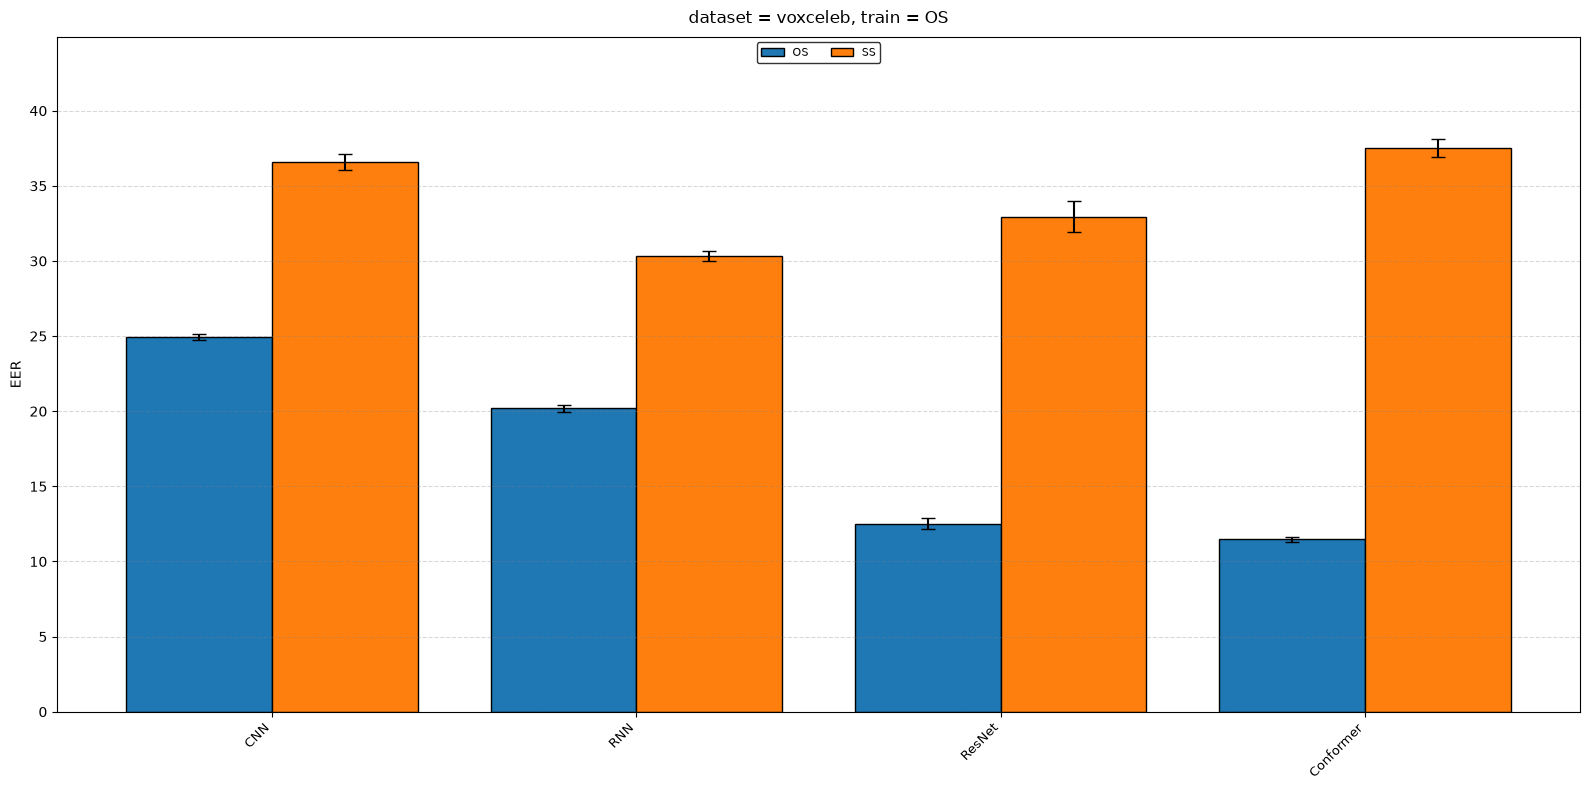

In [4]:
#| label: figure-conformer-vs-others-voxceleb
#| caption: EER depends on architecture complexity; The most complex architecture (Conformer) scores the lowest EER on OS data.

# Filter for OS and SS training strategies only
df_filtered_repro = df_repro[df_repro['train_strategy'].isin(['OS'])].copy()
#df_filtered_paper = df_paper[df_paper['train_strategy'].isin(['OS', 'SS'])].copy()

# Define fixed architecture order
architectures = ['CNN', 'RNN', 'ResNet', 'Conformer']

# Get unique datasets and training strategies
datasets = ['voxceleb'] #sorted(df_filtered_repro['dataset'].unique())
train_strategies = sorted(df_filtered_repro['train_strategy'].unique())
test_strategies = ['OS', 'SS'] # sorted(df_filtered_repro['test_strategy'].unique())

# Set up the 2x2 grid: rows=datasets, cols=training_strategies
fig, axes = plt.subplots(len(datasets), len(train_strategies),
                         figsize=(16, 8), sharey='row')

# If only one row or column, axes will be 1D, so we need to handle that
if len(datasets) == 1:
    None # axes = axes.reshape(1, -1)
if len(train_strategies) == 1:
    None # axes = axes.reshape(-1, 1)

# Define colors for test strategies
colors = {'OS': '#1f77b4', 'SS': '#ff7f0e', 'SU': '#2ca02c'}
labels = {'OS': 'OS', 'SS': 'SS', 'SU': 'SU'}

# Find global max for y-axis alignment (from both repro and paper)
# Calculate max per dataset for y-axis alignment
dataset_max = {}
for dataset in datasets:
    dataset_data_repro = df_filtered_repro[df_filtered_repro['dataset'] == dataset]
    #dataset_data_paper = df_filtered_paper[df_filtered_paper['dataset'] == dataset]
    eer_max_repro = dataset_data_repro['eer_mean'] + dataset_data_repro['eer_std']
    #eer_max_paper = dataset_data_paper['eer_mean'] + dataset_data_paper['eer_std']
    all_eer_max = pd.concat([eer_max_repro]) #, eer_max_paper])
    dataset_max[dataset] = max(all_eer_max) * 1.15

# Determine bar width based on number of test strategies
n_test = len(test_strategies)
bar_width = 0.8 / n_test

# Plot for each dataset and training strategy
for i, dataset in enumerate(datasets):
    for j, train_strategy in enumerate(train_strategies):
        #ax = axes[i, j]
        ax = axes

        # Get data (repro)
        subset_repro = df_filtered_repro[(df_filtered_repro['dataset'] == dataset) &
                              (df_filtered_repro['train_strategy'] == train_strategy)]

        # Get data (paper)
        #subset_paper = df_filtered_paper[(df_filtered_paper['dataset'] == dataset) &
                              #(df_filtered_paper['train_strategy'] == train_strategy)]

        # Get architectures (preserving order)
        subset_architectures = [arch for arch in architectures if arch in subset_repro['architecture'].unique()]

        if not subset_architectures:
            ax.set_title(f'{dataset}, Train: {train_strategy}', fontsize=12, pad=10)
            continue

        n_arch = len(subset_architectures)
        x = np.arange(n_arch)

        # Plot each test strategy
        for k, test_strategy in enumerate(test_strategies):
            offset = (k - (n_test - 1) / 2) * bar_width

            # Paper shadow bars
            #paper_arch_to_eer = {}
            #paper_arch_to_std = {}
            #if len(subset_paper) > 0:
            #    test_data_paper = subset_paper[subset_paper['test_strategy'] == test_strategy]
            #    for _, row in test_data_paper.iterrows():
            #        paper_arch_to_eer[row['architecture']] = row['eer_mean']
            #        paper_arch_to_std[row['architecture']] = row['eer_std']

            #paper_means = [paper_arch_to_eer.get(arch, None) for arch in subset_architectures]
            #paper_stds = [paper_arch_to_std.get(arch, None) for arch in subset_architectures]

            #paper_x, paper_means_filt, paper_stds_filt = [], [], []
            #for idx, (mean, std) in enumerate(zip(paper_means, paper_stds)):
            #    if mean is not None:
            #        paper_x.append(x[idx] + offset)
            #        paper_means_filt.append(mean)
            #        paper_stds_filt.append(std)

            #if len(paper_x) > 0:
            #    ax.bar(paper_x, paper_means_filt, bar_width,
            #           yerr=paper_stds_filt, capsize=5,
            #           color=colors[test_strategy],
            #           alpha=0.4, edgecolor='none',
            #           label=f'{test_strategy} (paper)')

            # Repro solid bars
            test_data_repro = subset_repro[subset_repro['test_strategy'] == test_strategy]
            arch_to_eer = {}
            arch_to_std = {}
            for _, row in test_data_repro.iterrows():
                arch_to_eer[row['architecture']] = row['eer_mean']
                arch_to_std[row['architecture']] = row['eer_std']

            eer_means = [arch_to_eer.get(arch, 0) for arch in subset_architectures]
            eer_stds = [arch_to_std.get(arch, 0) for arch in subset_architectures]

            ax.bar(x + offset, eer_means, bar_width,
                   yerr=eer_stds, capsize=5,
                   color=colors[test_strategy],
                   alpha=1.0, edgecolor='black',
                   label=labels[test_strategy])

        # Customize plot
        ax.set_title(f'dataset = {dataset}, train = {train_strategy}', fontsize=12, pad=10)
        ax.set_ylabel('EER', fontsize=10)
        ax.set_ylim(0, dataset_max[dataset])
        ax.set_xticks(x)
        ax.set_xticklabels(subset_architectures, rotation=45, ha='right', fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.legend(loc='upper center', fontsize=8, ncol=len(test_strategies))

plt.tight_layout()

The test results of OS-trained architectures show individual relative EER difference when tested with OS and SS data. However, the magnitude of the observed relative differences is proportional to the corresponding's architecture complexity. This leads to the conclusion, that a more complex architecture tends to be better at exploiting SST information (@figure-relative-difference-voxceleb-os-vs-ss).

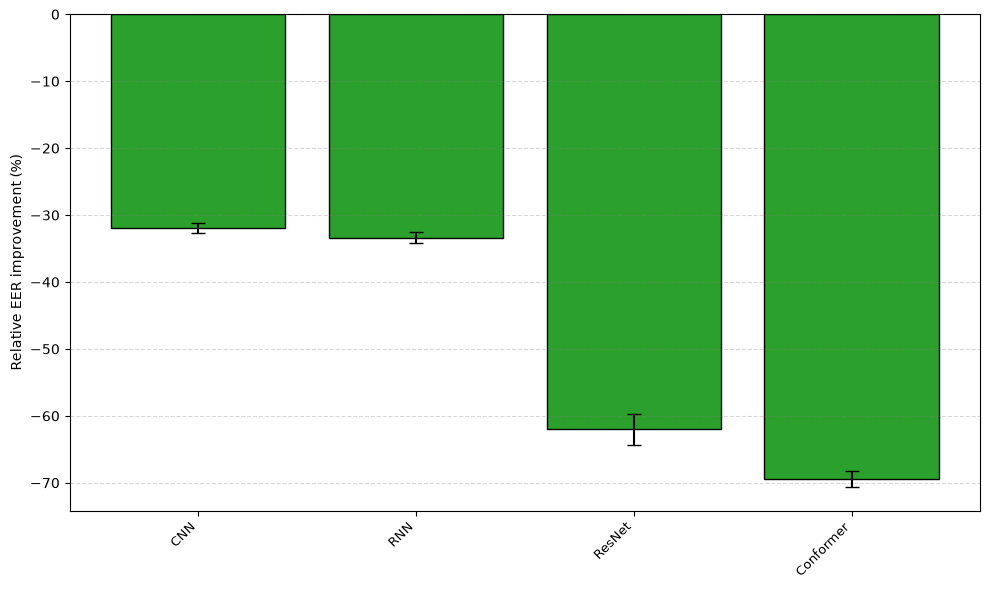

In [5]:
#| label: figure-relative-difference-voxceleb-os-vs-ss
#| caption: Relative difference of OS compared to SS results for each architecture trained on OS data. The Conformer shows the biggest relative difference ($-69.44 \% \pm 1.20$).

# Plot relative difference for voxceleb dataset: EER(test=OS) vs EER(test=SS) with train=OS
# Filter for voxceleb dataset, OS training strategy
df_voxceleb_os = df_repro[(df_repro['dataset'] == 'voxceleb') & (df_repro['train_strategy'] == 'OS')].copy()

# Define fixed architecture order
architectures = ['CNN', 'RNN', 'ResNet', 'Conformer']

# Get architectures present in voxceleb OS data
voxceleb_architectures = [arch for arch in architectures if arch in df_voxceleb_os['architecture'].unique()]

# Calculate relative differences and errors
rel_differences = []
rel_errors = []
arch_labels = []

for arch in voxceleb_architectures:
    # Get EER for test=OS and test=SS
    arch_data = df_voxceleb_os[df_voxceleb_os['architecture'] == arch]
    eer_os_row = arch_data[arch_data['test_strategy'] == 'OS']
    eer_ss_row = arch_data[arch_data['test_strategy'] == 'SS']

    if len(eer_os_row) > 0 and len(eer_ss_row) > 0:
        eer_os = eer_os_row['eer_mean'].values[0]
        eer_ss = eer_ss_row['eer_mean'].values[0]
        std_os = eer_os_row['eer_std'].values[0]
        std_ss = eer_ss_row['eer_std'].values[0]

        # Relative difference: (EER_OS - EER_SS) / EER_SS * 100%
        # This shows how much better OS testing is compared to SS testing
        rel_diff = ((eer_os - eer_ss) / eer_ss) * 100

        # Error propagation for relative difference
        # For f = (x - y) / y where x = eer_os, y = eer_ss
        if eer_ss != 0:
            term1 = (std_os / eer_ss) ** 2
            term2 = ((eer_os - eer_ss) / (eer_ss ** 2) * std_ss) ** 2
            rel_error = (term1 + term2) ** 0.5 * 100  # Convert to percent
        else:
            rel_error = 0

        rel_differences.append(rel_diff)
        rel_errors.append(rel_error)
        arch_labels.append(arch)
    else:
        rel_differences.append(0)
        rel_errors.append(0)
        arch_labels.append(arch)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Set up x positions
n_arch = len(arch_labels)
x = np.arange(n_arch)

# Plot bars with error bars
ax.bar(x, rel_differences, yerr=rel_errors, capsize=5,
       color='#2ca02c', alpha=1.0, edgecolor='black')

# Customize the plot
ax.set_ylabel('Relative EER improvement (%)', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(arch_labels, rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)  # Zero reference line

# Adjust layout
plt.tight_layout()

We expect a "result in one order of magnitude lower error rates" @doi:10.1016/j.patrec.2024.03.016 for any architecture fully exploiting SST information. One order of magnitude is a relative difference of $-90 \%$ when comparing the resulting EER of SS and OS data (if the architecture was trained on OS data). Even though our best result is quite good, the Conformer's relative EER difference is still below expectation ($-69.44 \% \pm 1.20$, @figure-relative-difference-voxceleb-os-vs-ss).

# Justification for Out-of-Distribution Testing

Arguably the main reason why architectures trained on OS data perform bad on SS data is because of the distribution shift – and not because they are ignoring SST information. @figure-train-test-in-distribution shows the training and test results of the different architectures within their corresponding data distribution of VoxCeleb. Again we see an improvement of the EER proportionally to the architecture complexity. And $EER(train=OS, test=OS)$ is lower than $EER(train=SS, test=SS)$ across all architectures.

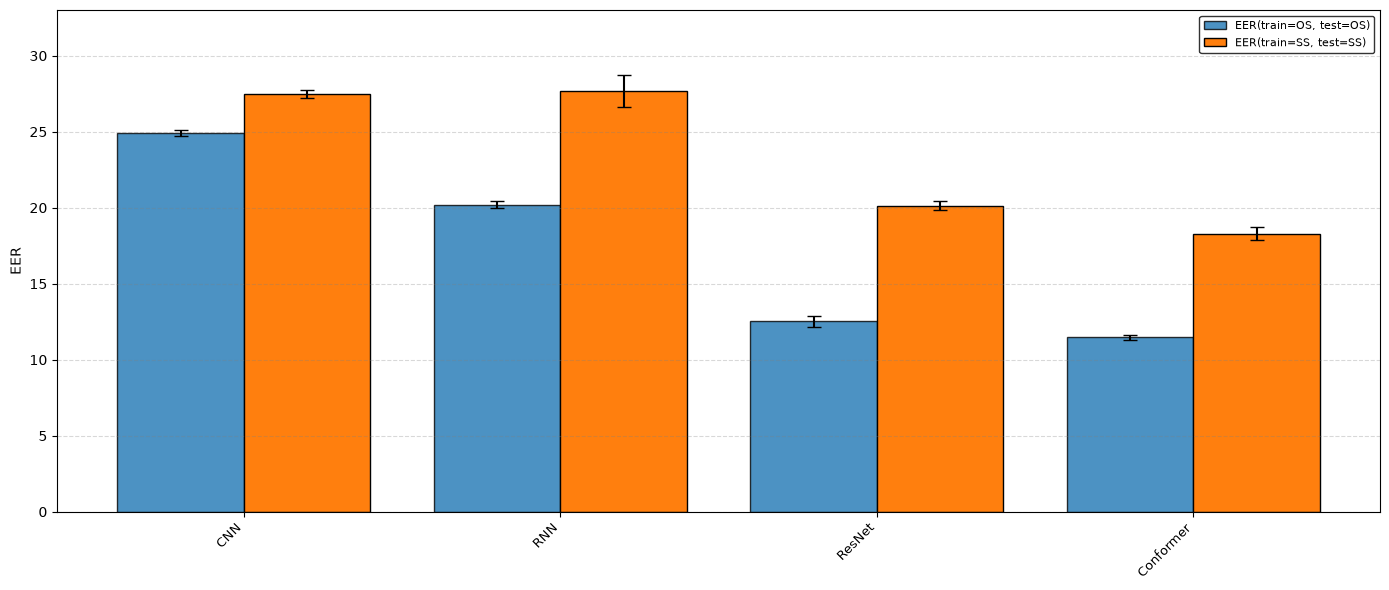

In [6]:
#| label: figure-train-test-in-distribution
#| caption: Train and test results for the different architectures within data distributions; For each architecture $EER(train=OS, test=OS)$ is lower than $EER(train=SS, test=SS)$.

# Plot EER(train=OS, test=OS) vs EER(train=SS, test=SS) per Architecture
# Filter for OS and SS training strategies
df_filtered = df_repro[df_repro['train_strategy'].isin(['OS', 'SS'])].copy()

# Define fixed architecture order
architectures = ['CNN', 'RNN', 'ResNet', 'Conformer']

# Get unique datasets
datasets = ['voxceleb'] # sorted(df_filtered['dataset'].unique())

# Define colors for the two strategies
colors = {'OS-OS': '#1f77b4', 'SS-SS': '#ff7f0e'}
labels = {'OS-OS': 'EER(train=OS, test=OS)', 'SS-SS': 'EER(train=SS, test=SS)'}

# Calculate global max for y-axis alignment
all_eers = []
all_errors = []
for dataset in datasets:
    os_os_data = df_filtered[(df_filtered['dataset'] == dataset) &
                           (df_filtered['train_strategy'] == 'OS') &
                           (df_filtered['test_strategy'] == 'OS')]
    ss_ss_data = df_filtered[(df_filtered['dataset'] == dataset) &
                           (df_filtered['train_strategy'] == 'SS') &
                           (df_filtered['test_strategy'] == 'SS')]
    for arch in architectures:
        for data, key in [(os_os_data, 'OS-OS'), (ss_ss_data, 'SS-SS')]:
            row = data[data['architecture'] == arch]
            if len(row) > 0:
                all_eers.append(row['eer_mean'].values[0] + row['eer_std'].values[0])
                all_errors.append(row['eer_std'].values[0])

global_max = max(all_eers) * 1.15 if all_eers else 1.0
global_err_max = max(all_errors) * 1.15 if all_errors else 1.0

# Set up 1x2 grid for 2 datasets
fig, axes = plt.subplots(1, len(datasets), figsize=(14, 6), sharey=True)

# Handle single dataset case
if len(datasets) == 1:
    axes = [axes]

bar_width = 0.4  # Width for each bar

# Create bar charts for each dataset
for i, dataset in enumerate(datasets):
    ax = axes[i]

    # Get data for this dataset
    os_os_data = df_filtered[(df_filtered['dataset'] == dataset) &
                           (df_filtered['train_strategy'] == 'OS') &
                           (df_filtered['test_strategy'] == 'OS')]
    ss_ss_data = df_filtered[(df_filtered['dataset'] == dataset) &
                           (df_filtered['train_strategy'] == 'SS') &
                           (df_filtered['test_strategy'] == 'SS')]

    # Get architectures present in this dataset
    dataset_architectures = [arch for arch in architectures if arch in df_filtered[df_filtered['dataset'] == dataset]['architecture'].unique()]

    n_arch = len(dataset_architectures)
    x = np.arange(n_arch)

    # Plot OS-OS bars
    os_os_means = []
    os_os_stds = []
    for arch in dataset_architectures:
        row = os_os_data[os_os_data['architecture'] == arch]
        if len(row) > 0:
            os_os_means.append(row['eer_mean'].values[0])
            os_os_stds.append(row['eer_std'].values[0])
        else:
            os_os_means.append(0)
            os_os_stds.append(0)
    ax.bar(x - bar_width/2, os_os_means, bar_width,
           yerr=os_os_stds, capsize=5,
           color=colors['OS-OS'], alpha=0.8, edgecolor='black',
           label=labels['OS-OS'])

    # Plot SS-SS bars
    ss_ss_means = []
    ss_ss_stds = []
    for arch in dataset_architectures:
        row = ss_ss_data[ss_ss_data['architecture'] == arch]
        if len(row) > 0:
            ss_ss_means.append(row['eer_mean'].values[0])
            ss_ss_stds.append(row['eer_std'].values[0])
        else:
            ss_ss_means.append(0)
            ss_ss_stds.append(0)
    ax.bar(x + bar_width/2, ss_ss_means, bar_width,
           yerr=ss_ss_stds, capsize=5,
           color=colors['SS-SS'], alpha=1.0, edgecolor='black',
           label=labels['SS-SS'])

    # Customize the plot
    ax.set_ylabel('EER', fontsize=10)
    ax.set_ylim(0, global_max)
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_architectures, rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()

@figure-relative-difference-voxceleb-in-distribution shows the relative difference between the two in-distribution EER test results. Notably, the difference between ResNet and the Conformer architecture are very similar. However, it is unclear how to interpret these results as the expected EER improvement claim (@doi:10.1016/j.patrec.2024.03.016) origins from a study conducted with human participants (@10.1145/1631272.1631300). And because the human brain is trained on OS data we argue that the relative difference of in-distribution error rates are not a good metric for SST exploitation.

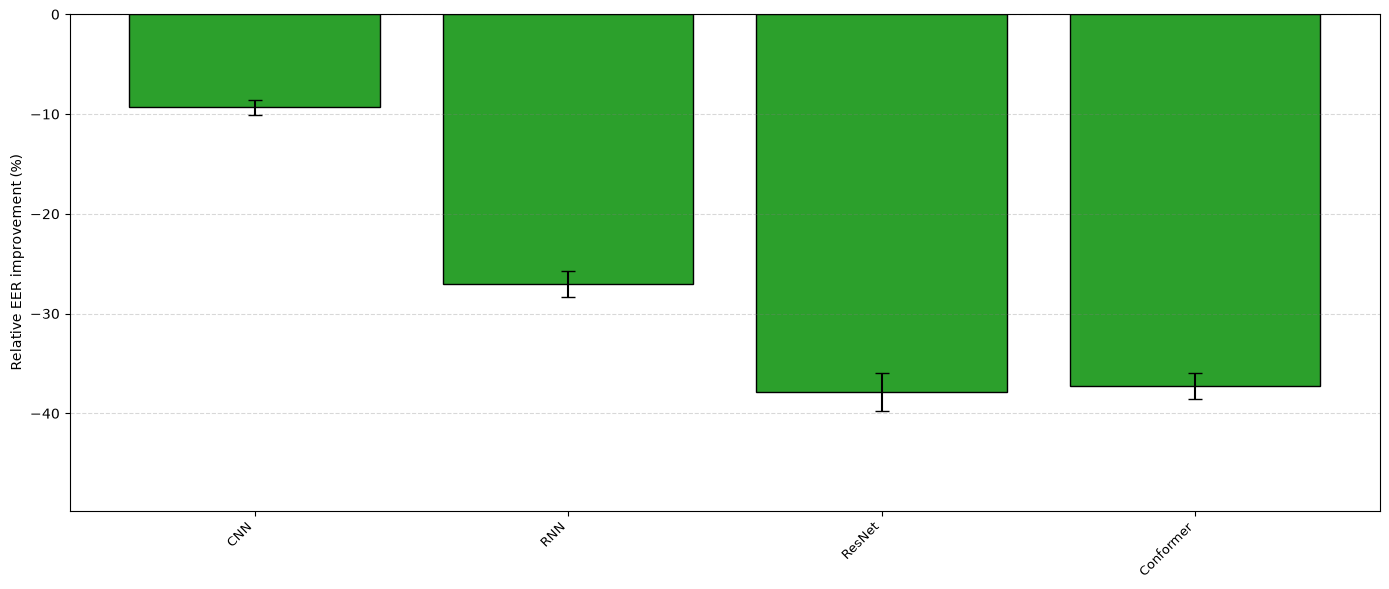

In [7]:
#| label: figure-relative-difference-voxceleb-in-distribution
#| caption: Relative difference for in-distribution error rates $EER(train=SS, test=SS)$ and $EER(train=OS, train=OS)$
# Plot relative EER difference: EER(train=SS, test=SS) vs EER(train=OS, test=OS) for each architecture and dataset
# Filter for OS and SS training strategies with matching test strategies
df_os_os = df_repro[(df_repro['train_strategy'] == 'OS') & (df_repro['test_strategy'] == 'OS')].copy()
df_ss_ss = df_repro[(df_repro['train_strategy'] == 'SS') & (df_repro['test_strategy'] == 'SS')].copy()

# Define fixed architecture order
architectures = ['CNN', 'RNN', 'ResNet', 'Conformer']

# Get unique datasets
datasets = ['voxceleb'] # sorted(df_repro['dataset'].unique())

# Calculate global max for y-axis alignment
all_rel_diffs = []
all_rel_errors = []

for dataset in datasets:
    for arch in architectures:
        # Get EER for train=OS,test=OS and train=SS,test=SS for this dataset
        os_os_row = df_os_os[(df_os_os['dataset'] == dataset) & (df_os_os['architecture'] == arch)]
        ss_ss_row = df_ss_ss[(df_ss_ss['dataset'] == dataset) & (df_ss_ss['architecture'] == arch)]
        
        if len(os_os_row) > 0 and len(ss_ss_row) > 0:
            eer_os_os = os_os_row['eer_mean'].values[0]
            eer_ss_ss = ss_ss_row['eer_mean'].values[0]
            std_os_os = os_os_row['eer_std'].values[0]
            std_ss_ss = ss_ss_row['eer_std'].values[0]
            
            # Relative difference: (EER(train=OS, test=OS) - EER(train=SS, test=SS)) / EER(train=SS, test=SS) * 100%
            rel_diff = ((eer_os_os - eer_ss_ss) / eer_ss_ss) * 100
            
            # Error propagation for relative difference
            # For f = (x - y) / y where x = eer_os_os, y = eer_ss_ss
            if eer_ss_ss != 0:
                term1 = (std_os_os / eer_ss_ss) ** 2
                term2 = ((eer_os_os - eer_ss_ss) / (eer_ss_ss ** 2) * std_ss_ss) ** 2
                rel_error = (term1 + term2) ** 0.5 * 100  # Convert to percent
            else:
                rel_error = 0
            
            all_rel_diffs.append(abs(rel_diff))
            all_rel_errors.append(rel_error)

# Calculate global max for y-axis alignment
global_max = (max(all_rel_diffs) + max(all_rel_errors)) * 1.25 if all_rel_diffs and all_rel_errors else 1.0

# Set up 1x2 grid for 2 datasets
fig, axes = plt.subplots(1, len(datasets), figsize=(14, 6), sharey=True)

# Handle single dataset case
if len(datasets) == 1:
    axes = [axes]

# Create bar charts for each dataset
for i, dataset in enumerate(datasets):
    ax = axes[i]
    
    # Get data for this dataset
    dataset_architectures = [arch for arch in architectures if arch in df_os_os[df_os_os['dataset'] == dataset]['architecture'].unique()]
    
    # Calculate relative differences and errors
    rel_differences = []
    rel_errors = []
    
    for arch in dataset_architectures:
        os_os_row = df_os_os[(df_os_os['dataset'] == dataset) & (df_os_os['architecture'] == arch)]
        ss_ss_row = df_ss_ss[(df_ss_ss['dataset'] == dataset) & (df_ss_ss['architecture'] == arch)]
        
        if len(os_os_row) > 0 and len(ss_ss_row) > 0:
            eer_os_os = os_os_row['eer_mean'].values[0]
            eer_ss_ss = ss_ss_row['eer_mean'].values[0]
            std_os_os = os_os_row['eer_std'].values[0]
            std_ss_ss = ss_ss_row['eer_std'].values[0]
            
            # Relative difference: (EER(train=OS, test=OS) - EER(train=SS, test=SS)) / EER(train=SS, test=SS) * 100%
            rel_diff = ((eer_os_os - eer_ss_ss) / eer_ss_ss) * 100
            
            # Error propagation
            if eer_ss_ss != 0:
                term1 = (std_os_os / eer_ss_ss) ** 2
                term2 = ((eer_os_os - eer_ss_ss) / (eer_ss_ss ** 2) * std_ss_ss) ** 2
                rel_error = (term1 + term2) ** 0.5 * 100
            else:
                rel_error = 0
            
            rel_differences.append(rel_diff)
            rel_errors.append(rel_error)
        else:
            rel_differences.append(0)
            rel_errors.append(0)
    
    # Set up x positions
    n_arch = len(dataset_architectures)
    x = np.arange(n_arch)
    
    # Plot bars with error bars
    ax.bar(x, rel_differences, yerr=rel_errors, capsize=5,
           color='#2ca02c', alpha=1.0, edgecolor='black')
    
    # Customize the plot
    ax.set_ylabel('Relative EER improvement (%)', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_architectures, rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylim(-global_max, 0)  # Symmetric around zero

plt.tight_layout()